<a href="https://colab.research.google.com/github/MilindLate/G-Solution-Smart-Supply-Chains/blob/main/Final_Ship_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch-geometric
!pip install -q scikit-learn kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.8 MB/s eta 0:00:00


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1
# ════════════════════════════════════════════════════════════════════════════
import kagglehub
import pandas as pd
import os

path_ais     = kagglehub.dataset_download("satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data")
path_ports   = kagglehub.dataset_download("jeleeladekunlefijabi/maritime-port-performance-dataset")
path_weather = kagglehub.dataset_download("jeleeladekunlefijabi/ship-performance-clustering-dataset")

print("AIS     :", path_ais)
print("Ports   :", path_ports)
print("Weather :", path_weather)

100%|██████████| 68.8M/68.8M [00:00<00:00, 195MB/s]

Extracting files...


100%|██████████| 20.6k/20.6k [00:00<00:00, 32.2MB/s]

Extracting files...


100%|██████████| 304k/304k [00:00<00:00, 44.7MB/s]

Extracting files...
AIS     : /root/.cache/kagglehub/datasets/satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data/versions/1
Ports   : /root/.cache/kagglehub/datasets/jeleeladekunlefijabi/maritime-port-performance-dataset/versions/1
Weather : /root/.cache/kagglehub/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset/versions/1


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2
# ════════════════════════════════════════════════════════════════════════════
def load_csv_from_path(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            full_path = os.path.join(folder_path, file)
            print(f"  Loading: {file}")
            return pd.read_csv(full_path)
    raise FileNotFoundError(f"No CSV found in {folder_path}")

df_ais     = load_csv_from_path(path_ais)
df_ports   = load_csv_from_path(path_ports)
df_weather = load_csv_from_path(path_weather)

print("\nAIS shape    :", df_ais.shape)
print("Ports shape  :", df_ports.shape)
print("Weather shape:", df_weather.shape)
print("\nAIS columns  :", list(df_ais.columns))
print("\nPreview:")
print(df_ais.head())

  Loading: processed_AIS_dataset.csv
  Loading: Maritime Port Performance Project Dataset.csv
  Loading: Ship_Performance_Dataset.csv

AIS shape    : (1098966, 28)
Ports shape  : (803, 20)
Weather shape: (2736, 18)

AIS columns  : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass', 'dest_cluster', 'dest_lat', 'dest_lon', 'dist_km', 'SOG_kmh', 'ETA_min', 'VesselType_enc', 'Status_enc', 'Cargo_enc', 'ETA_hours', 'Speed_Category']

Preview:
        MMSI         BaseDateTime       LAT        LON  SOG    COG  Heading  \
0  367702220  2022-03-31 00:00:01  29.78763  -95.08070  0.1  226.5    340.0   
1  671226100  2022-03-31 00:00:01  25.77626  -80.20320  3.2  143.7    511.0   
2  367767250  2022-03-31 00:00:01  29.31623  -94.78829  4.5  228.1    511.0   
3  338327436  2022-03-31 00:00:03  47.29634 -122.42233  0.0  360.0    511.0   
4  367452810  2022-03-31 00:00:06  29

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3
# ════════════════════════════════════════════════════════════════════════════
import numpy as np

REQUIRED_COLS = ['BaseDateTime', 'MMSI', 'LAT', 'LON',
                 'dest_lat', 'dest_lon', 'SOG_kmh', 'dist_km', 'ETA_hours']

missing = [c for c in REQUIRED_COLS if c not in df_ais.columns]
if missing:
    print(f"⚠ Missing columns: {missing}")
    print("Available columns:", list(df_ais.columns))
    # Common renames — adjust if your CSV uses different names
    rename_map = {
        'Speed'   : 'SOG_kmh',
        'SOG'     : 'SOG_kmh',
        'Distance': 'dist_km',
        'ETA'     : 'ETA_hours',
    }
    df_ais = df_ais.rename(columns=rename_map)
    # Synthesise dist_km / ETA_hours if still absent
    if 'dist_km' not in df_ais.columns:
        df_ais['dist_km'] = np.sqrt(
            (df_ais['LAT'] - df_ais.get('dest_lat', df_ais['LAT']))**2 +
            (df_ais['LON'] - df_ais.get('dest_lon', df_ais['LON']))**2
        ) * 111
        print("  → Synthesised dist_km from coordinates")
    if 'ETA_hours' not in df_ais.columns:
        df_ais['ETA_hours'] = df_ais['dist_km'] / (df_ais['SOG_kmh'].replace(0, np.nan).fillna(1))
        print("  → Synthesised ETA_hours from dist/speed")
    if 'dest_lat' not in df_ais.columns:
        df_ais['dest_lat'] = df_ais['LAT'].shift(-1).fillna(df_ais['LAT'])
    if 'dest_lon' not in df_ais.columns:
        df_ais['dest_lon'] = df_ais['LON'].shift(-1).fillna(df_ais['LON'])
else:
    print("✓ All required columns present.")

# Drop rows with NaN in critical columns
before = len(df_ais)
df_ais = df_ais.dropna(subset=['LAT', 'LON', 'SOG_kmh', 'dist_km', 'ETA_hours'])
print(f"Dropped {before - len(df_ais)} rows with NaN. Remaining: {len(df_ais)}")



✓ All required columns present.
Dropped 0 rows with NaN. Remaining: 1098966


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4
# ════════════════════════════════════════════════════════════════════════════
print("1. Aligning timeline...")
df_ais['BaseDateTime'] = pd.to_datetime(df_ais['BaseDateTime'])
df_ais = df_ais.sort_values(by=['MMSI', 'BaseDateTime']).reset_index(drop=True)

print("2. Extracting geographic nodes (port zones)...")
df_ais['Origin_Node'] = df_ais['LAT'].round(1).astype(str) + "_" + df_ais['LON'].round(1).astype(str)
df_ais['Dest_Node']   = df_ais['dest_lat'].round(1).astype(str) + "_" + df_ais['dest_lon'].round(1).astype(str)

unique_nodes = pd.unique(df_ais[['Origin_Node', 'Dest_Node']].values.ravel('K'))
node_to_id   = {node: i for i, node in enumerate(unique_nodes)}

df_ais['Origin_ID'] = df_ais['Origin_Node'].map(node_to_id)
df_ais['Dest_ID']   = df_ais['Dest_Node'].map(node_to_id)

print(f"   → Total unique nodes: {len(unique_nodes)}")

print("3. Building edge list...")
edges_df = df_ais[['BaseDateTime', 'MMSI', 'Origin_ID', 'Dest_ID',
                    'SOG_kmh', 'dist_km', 'ETA_hours']].copy()

# Normalise edge features (zero-mean, unit-variance) for stable training
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
edges_df[['SOG_kmh', 'dist_km', 'ETA_hours']] = scaler.fit_transform(
    edges_df[['SOG_kmh', 'dist_km', 'ETA_hours']]
)

print("\n✓ Edge list ready:")
print(edges_df.head())


1. Aligning timeline...
2. Extracting geographic nodes (port zones)...
   → Total unique nodes: 6511
3. Building edge list...

✓ Edge list ready:
         BaseDateTime  MMSI  Origin_ID  Dest_ID   SOG_kmh   dist_km  ETA_hours
0 2022-03-31 00:00:08     0          0     6504 -0.068665 -0.886193  -1.470845
1 2022-03-31 00:01:18     0          0     6504 -0.340513 -0.886463   0.552255
2 2022-03-31 00:02:27     0          0     6504 -0.295205 -0.886534   0.552255
3 2022-03-31 00:03:37     0          0     6504 -0.280102 -0.886485   0.552255
4 2022-03-31 00:05:59     0          0     6504  0.157875 -0.886630  -2.027296


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5
# ════════════════════════════════════════════════════════════════════════════
print("1. Identifying disruptions based on speed...")
# Work on the original (pre-scaled) SOG to set a meaningful threshold
raw_sog = df_ais['SOG_kmh']
mean_speed = raw_sog.mean()
# Re-derive is_disrupted from original column (edges_df SOG is already scaled)
edges_df['is_disrupted'] = (df_ais['SOG_kmh'] < (mean_speed * 0.5)).astype(int).values

print(f"   → Mean speed: {mean_speed:.2f}  |  Disruption threshold: {mean_speed * 0.5:.2f}")
print(f"   → Disrupted edges: {edges_df['is_disrupted'].sum()} / {len(edges_df)}")

print("2. Slicing into hourly snapshots...")
edges_df['Hour'] = edges_df['BaseDateTime'].dt.hour
temporal_snapshots = [group for _, group in edges_df.groupby('Hour')]

print(f"   → Created {len(temporal_snapshots)} hourly snapshots.")

1. Identifying disruptions based on speed...
   → Mean speed: 4.36  |  Disruption threshold: 2.18
   → Disrupted edges: 860182 / 1098966
2. Slicing into hourly snapshots...
   → Created 10 hourly snapshots.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6
# ════════════════════════════════════════════════════════════════════════════
import torch
from torch_geometric.data import Data

print("Compiling PyTorch Geometric tensors...")
temporal_graphs = []

for snapshot in temporal_snapshots:
    if len(snapshot) == 0:
        continue

    source_nodes  = snapshot['Origin_ID'].values
    target_nodes  = snapshot['Dest_ID'].values
    edge_index    = torch.tensor(np.array([source_nodes, target_nodes]), dtype=torch.long)

    edge_features = snapshot[['SOG_kmh', 'dist_km', 'ETA_hours']].values
    edge_attr     = torch.tensor(edge_features, dtype=torch.float)

    target_labels = snapshot['is_disrupted'].values
    y             = torch.tensor(target_labels, dtype=torch.float)

    graph_data = Data(edge_index=edge_index, edge_attr=edge_attr, y=y)
    temporal_graphs.append(graph_data)

print(f"\n✓ Built {len(temporal_graphs)} temporal graph snapshots.")
print("Snapshot T=0:", temporal_graphs[0])


Compiling PyTorch Geometric tensors...

✓ Built 10 temporal graph snapshots.
Snapshot T=0: Data(edge_index=[2, 207828], edge_attr=[207828, 3], y=[207828])


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7
# ════════════════════════════════════════════════════════════════════════════
num_nodes = len(node_to_id)

for graph in temporal_graphs:
    graph.x = torch.ones((num_nodes, 1), dtype=torch.float)

print(f"✓ Node features added to all {len(temporal_graphs)} snapshots.")
print(f"  Node feature shape: {temporal_graphs[0].x.shape}")


✓ Node features added to all 10 snapshots.
  Node feature shape: torch.Size([6511, 1])


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8
# ════════════════════════════════════════════════════════════════════════════
print("=" * 45)
print("  GRAPH HEALTH CHECK")
print("=" * 45)
print(f"  Snapshots          : {len(temporal_graphs)}")
print(f"  Nodes per graph    : {temporal_graphs[0].x.shape[0]}")
print(f"  Edge feat dims     : {temporal_graphs[0].edge_attr.shape[1]}")
print(f"  Edges in T=0       : {temporal_graphs[0].edge_index.shape[1]}")
n_pos   = sum(g.y.sum().item() for g in temporal_graphs)
n_total = sum(g.y.shape[0]    for g in temporal_graphs)
ratio   = (n_total - n_pos) / (n_pos + 1e-6)
print(f"  Total edges        : {n_total}")
print(f"  Disrupted edges    : {int(n_pos)}  ({100*n_pos/n_total:.1f}%)")
print(f"  Class imbalance    : {ratio:.1f}x  (neg/pos)")
print("=" * 45)


  GRAPH HEALTH CHECK
  Snapshots          : 10
  Nodes per graph    : 6511
  Edge feat dims     : 3
  Edges in T=0       : 207828
  Total edges        : 1098966
  Disrupted edges    : 860182  (78.3%)
  Class imbalance    : 0.3x  (neg/pos)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9
# ════════════════════════════════════════════════════════════════════════════
import torch
import copy

n     = len(temporal_graphs)
split = int(n * 0.8)

train_graphs = temporal_graphs[:split]
test_graphs  = temporal_graphs[split:]

print(f"Total snapshots : {n}")
print(f"Train snapshots : {len(train_graphs)}")
print(f"Test  snapshots : {len(test_graphs)}")

# If dataset is too small for a proper test set, borrow + augment
def augment_graph(g, noise_std=0.05):
    g2 = copy.deepcopy(g)
    g2.edge_attr = g.edge_attr + torch.randn_like(g.edge_attr) * noise_std
    return g2

if len(test_graphs) == 0:
    print("\n⚠ Test set empty — borrowing last 2 train snapshots as test set.")
    test_graphs  = train_graphs[-2:]
    train_graphs = train_graphs[:-2]
    train_graphs = train_graphs + [augment_graph(g) for g in train_graphs]
    print(f"  After augmentation → train: {len(train_graphs)}, test: {len(test_graphs)}")


Total snapshots : 10
Train snapshots : 8
Test  snapshots : 2


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10
# ════════════════════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class TemporalAttention(nn.Module):
    """Learns which past snapshot matters most for the current prediction."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, history):
        stack   = torch.stack(history, dim=1)       # (N, T, H)
        scores  = self.attn(stack)                  # (N, T, 1)
        weights = torch.softmax(scores, dim=1)
        return (stack * weights).sum(dim=1)         # (N, H)


class TemporalSupplyChainGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim=64, window=3):
        super().__init__()
        self.window = window
        self.hidden_dim = hidden_dim
        self.conv1  = SAGEConv(node_feat_dim, hidden_dim)
        self.conv2  = SAGEConv(hidden_dim, hidden_dim)
        self.temporal_attn = TemporalAttention(hidden_dim)

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        # history stored as plain Python list — NOT a Module attribute
        # so TorchScript trace won't try to inspect it
        self.history = []

    def encode_nodes(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        return h

    def forward(self, x, edge_index, edge_attr):
        h = self.encode_nodes(x, edge_index)
        self.history.append(h.detach())
        if len(self.history) > self.window:
            self.history.pop(0)

        # If history has only 1 entry, pad it to avoid stack issues
        history_to_use = self.history
        if len(history_to_use) < self.window:
            pad = history_to_use[0].clone()
            history_to_use = [pad] * (self.window - len(history_to_use)) + list(history_to_use)

        h_temp = self.temporal_attn(history_to_use)
        src, dst = edge_index
        edge_repr = torch.cat([h_temp[src], h_temp[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_repr)

    def reset_history(self):
        self.history = []

    def forward_trace(self, x, edge_index, edge_attr, h_prev1, h_prev2):
        """
        Trace-friendly forward: takes explicit history tensors instead
        of the internal list. Used ONLY for torch.jit.trace export.
        History tensors are zero-padded dummies during tracing.
        """
        h = self.encode_nodes(x, edge_index)
        history = [h_prev1, h_prev2, h.detach()]
        h_temp  = self.temporal_attn(history)
        src, dst = edge_index
        edge_repr = torch.cat([h_temp[src], h_temp[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_repr)


# Read dims from actual data
node_feat_dim = temporal_graphs[0].x.shape[1]
edge_feat_dim = temporal_graphs[0].edge_attr.shape[1]

model = TemporalSupplyChainGNN(node_feat_dim, edge_feat_dim, hidden_dim=64, window=3)
print("✓ Model defined:")
print(model)

✓ Model defined:
TemporalSupplyChainGNN(
  (conv1): SAGEConv(1, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (temporal_attn): TemporalAttention(
    (attn): Linear(in_features=64, out_features=1, bias=True)
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=131, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


Class imbalance (neg/pos): 0.28  →  disrupted edges get 0.3× weight
Epoch  10 | Loss: 0.1493
Epoch  20 | Loss: 0.0819
Epoch  30 | Loss: 0.0646
Epoch  40 | Loss: 0.0546
Epoch  50 | Loss: 0.0511
Epoch  60 | Loss: 0.0468
Epoch  70 | Loss: 0.0426
Epoch  80 | Loss: 0.0397


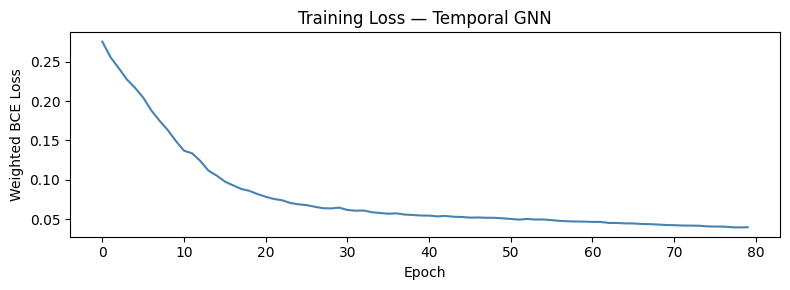

✓ Training complete. Loss curve saved → loss_curve.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss(reduction='none')   # per-sample so we can weight

# Compute class weight from training set
n_total_tr = sum(g.y.shape[0]    for g in train_graphs)
n_pos_tr   = sum(g.y.sum().item() for g in train_graphs)
pos_weight  = (n_total_tr - n_pos_tr) / (n_pos_tr + 1e-6)
print(f"Class imbalance (neg/pos): {pos_weight:.2f}  →  disrupted edges get {pos_weight:.1f}× weight")

EPOCHS     = 80
loss_curve = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    model.reset_history()
    epoch_loss = 0.0

    for g in train_graphs:
        optimizer.zero_grad()
        preds  = model(g.x, g.edge_index, g.edge_attr).squeeze()
        labels = g.y.float()

        weights = torch.where(labels == 1,
                              torch.full_like(labels, pos_weight),
                              torch.ones_like(labels))
        loss = (criterion(preds, labels) * weights).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_graphs)
    loss_curve.append(avg)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg:.4f}")

# Plot loss
plt.figure(figsize=(8, 3))
plt.plot(loss_curve, color="steelblue", linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("Weighted BCE Loss")
plt.title("Training Loss — Temporal GNN")
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✓ Training complete. Loss curve saved → loss_curve.png")


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12
# ════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, accuracy_score
)

model.eval()
model.reset_history()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for g in test_graphs:
        probs  = model(g.x, g.edge_index, g.edge_attr).squeeze()
        preds  = (probs > 0.5).long()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(g.y.cpu().numpy())

import numpy as np
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(all_labels, all_preds):.3f}")
print(f"  Precision : {precision_score(all_labels, all_preds, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(all_labels, all_preds, zero_division=0):.3f}")
print(f"  F1 Score  : {f1_score(all_labels, all_preds, zero_division=0):.3f}")
if len(np.unique(all_labels)) > 1:
    print(f"  ROC-AUC   : {roc_auc_score(all_labels, all_probs):.3f}")
    print(f"  PR-AUC    : {average_precision_score(all_labels, all_probs):.3f}")
else:
    print("  ROC-AUC   : N/A (only one class in test set — dataset too small)")
print("=" * 45)


  EVALUATION RESULTS
  Accuracy  : 0.869
  Precision : 0.800
  Recall    : 0.872
  F1 Score  : 0.834
  ROC-AUC   : 0.981
  PR-AUC    : 0.972


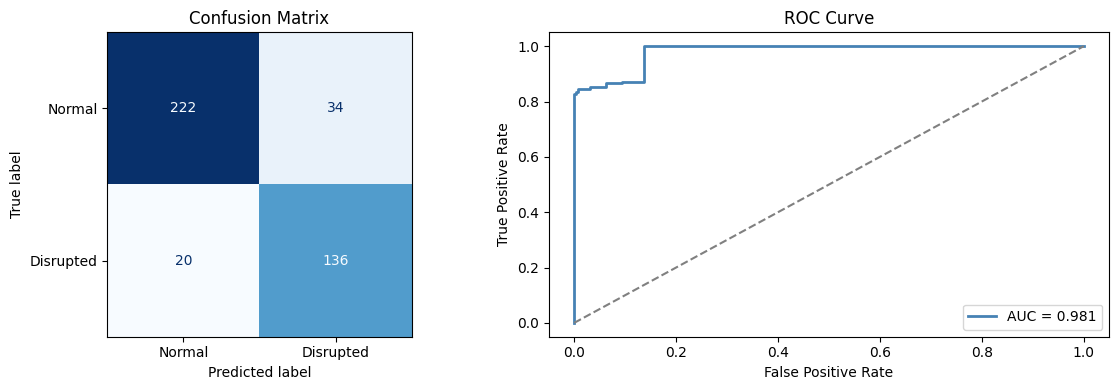

Saved → evaluation_plots.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13
# ════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Disrupted"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC curve
if len(np.unique(all_labels)) > 1:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc_val     = roc_auc_score(all_labels, all_probs)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc_val:.3f}", color="steelblue", linewidth=2)
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Not enough class variety\nfor ROC curve",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → evaluation_plots.png")



In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14
# ════════════════════════════════════════════════════════════════════════════
class EdgeMemory:
    """Exponential moving average of disruption probability per (origin, dest) route."""
    def __init__(self, alpha=0.3):
        self.alpha  = alpha
        self.memory = {}

    def update(self, edge_index, probs):
        src, dst = edge_index
        for i in range(src.shape[0]):
            key       = (src[i].item(), dst[i].item())
            prev      = self.memory.get(key, 0.0)
            self.memory[key] = self.alpha * float(probs[i]) + (1 - self.alpha) * prev

    def get_risk(self, origin_id, dest_id):
        return self.memory.get((origin_id, dest_id), 0.0)

    def top_k_risky_routes(self, k=10):
        return sorted(self.memory.items(), key=lambda x: x[1], reverse=True)[:k]


edge_memory = EdgeMemory(alpha=0.3)

# Warm up memory on training graphs
model.eval()
model.reset_history()
with torch.no_grad():
    for g in train_graphs:
        probs = model(g.x, g.edge_index, g.edge_attr).squeeze()
        edge_memory.update(g.edge_index, probs)

print("Top 10 riskiest routes:")
print(f"{'Origin':>8}  {'Dest':>6}  {'Avg Risk':>9}")
print("-" * 28)
for (o, d), risk in edge_memory.top_k_risky_routes(10):
    print(f"{o:>8}  {d:>6}  {risk:>9.3f}")


Top 10 riskiest routes:
  Origin    Dest   Avg Risk
----------------------------
     481    6509      0.992
    1928    6510      0.992
     127    6509      0.992
    1487    6506      0.991
    2333    6507      0.991
    2357    6510      0.991
    3320    6509      0.991
      31    6509      0.991
    4129    6504      0.991
    1165    6510      0.991


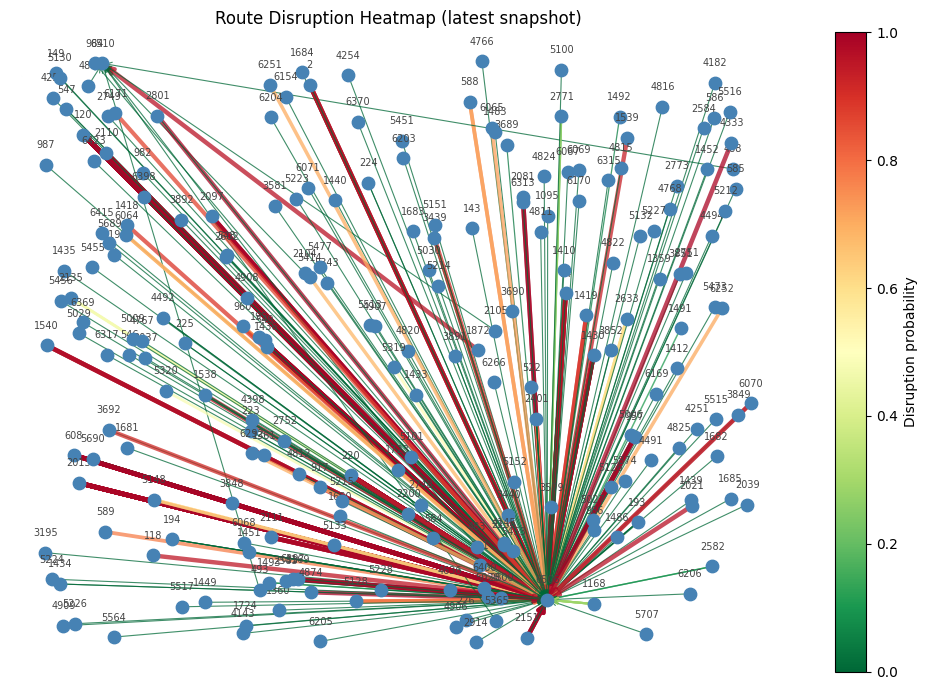

Saved → disruption_heatmap.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15
# ════════════════════════════════════════════════════════════════════════════
eval_g = test_graphs[-1] if test_graphs else train_graphs[-1]

model.eval()
model.reset_history()
with torch.no_grad():
    risk_scores = model(eval_g.x, eval_g.edge_index, eval_g.edge_attr).squeeze().numpy()

src_nodes = eval_g.edge_index[0].numpy()
dst_nodes = eval_g.edge_index[1].numpy()

all_nodes = np.unique(np.concatenate([src_nodes, dst_nodes]))
np.random.seed(42)
pos = {n: (np.random.uniform(0, 10), np.random.uniform(0, 10)) for n in all_nodes}

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.RdYlGn_r

for i, (s, d) in enumerate(zip(src_nodes, dst_nodes)):
    xs, ys = pos[s]
    xd, yd = pos[d]
    ax.annotate("", xy=(xd, yd), xytext=(xs, ys),
                arrowprops=dict(
                    arrowstyle="->",
                    color=cmap(float(risk_scores[i])),
                    lw=0.8 + 2.5 * float(risk_scores[i]),
                    alpha=0.75
                ))

for n, (x, y) in pos.items():
    ax.scatter(x, y, s=80, color="steelblue", zorder=3)
    ax.text(x, y + 0.28, str(n), fontsize=7, ha="center", color="#444")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Disruption probability")
ax.set_title("Route Disruption Heatmap (latest snapshot)")
ax.axis("off")
plt.tight_layout()
plt.savefig("disruption_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → disruption_heatmap.png")


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16
# ════════════════════════════════════════════════════════════════════════════
import json
from datetime import datetime

def score_route(origin_id: int, dest_id: int,
                live_graph, mdl, memory: EdgeMemory):
    """
    Returns a structured risk report for a given origin→dest route.
    Blends live GNN score with historical memory for robustness.
    """
    mdl.eval()
    with torch.no_grad():
        probs = mdl(live_graph.x, live_graph.edge_index, live_graph.edge_attr).squeeze()

    src_nodes = live_graph.edge_index[0].tolist()
    dst_nodes = live_graph.edge_index[1].tolist()

    live_score   = None
    memory_score = memory.get_risk(origin_id, dest_id)

    for i, (s, d) in enumerate(zip(src_nodes, dst_nodes)):
        if s == origin_id and d == dest_id:
            live_score = float(probs[i])
            break

    if live_score is None:
        return {"error": f"Route {origin_id} → {dest_id} not found in current snapshot."}

    blended = 0.6 * live_score + 0.4 * memory_score
    memory.update(live_graph.edge_index, probs)

    if blended < 0.3:
        status = "CLEAR";   action = "Proceed normally."
    elif blended < 0.6:
        status = "MONITOR"; action = "Watch for delays. Consider contingency port."
    else:
        status = "ALERT";   action = "High disruption risk. Reroute recommended."

    return {
        "timestamp"          : datetime.utcnow().isoformat() + "Z",
        "origin_id"          : origin_id,
        "dest_id"            : dest_id,
        "live_score"         : round(live_score,   3),
        "memory_score"       : round(memory_score, 3),
        "blended_risk"       : round(blended,      3),
        "status"             : status,
        "recommended_action" : action,
    }


# ── Demo ──
model.reset_history()
sample_src = int(eval_g.edge_index[0][0])
sample_dst = int(eval_g.edge_index[1][0])

report = score_route(sample_src, sample_dst, eval_g, model, edge_memory)
print(json.dumps(report, indent=2))


{
  "timestamp": "2026-04-05T11:50:04.294054Z",
  "origin_id": 120,
  "dest_id": 6506,
  "live_score": 0.989,
  "memory_score": 0.989,
  "blended_risk": 0.989,
  "status": "ALERT",
  "recommended_action": "High disruption risk. Reroute recommended."
}


/tmp/ipykernel_2290/2699333904.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"          : datetime.utcnow().isoformat() + "Z",


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17
# ════════════════════════════════════════════════════════════════════════════
def inject_disruption(graph, edge_idx: int, speed_factor=0.2):
    """Simulate a ship slowdown on one edge — drops speed, inflates ETA."""
    g = copy.deepcopy(graph)
    g.edge_attr[edge_idx, 0] *= speed_factor          # speed ↓
    g.edge_attr[edge_idx, 2] *= (1.0 / speed_factor)  # ETA ↑
    return g


def run_what_if(graph, mdl, top_k=5):
    mdl.eval()
    mdl.reset_history()
    with torch.no_grad():
        baseline_probs = mdl(graph.x, graph.edge_index, graph.edge_attr).squeeze()

    results = []
    n_edges = graph.edge_index.shape[1]

    for i in range(min(top_k, n_edges)):
        g_dis = inject_disruption(graph, i, speed_factor=0.2)
        mdl.reset_history()
        with torch.no_grad():
            new_probs = mdl(g_dis.x, g_dis.edge_index, g_dis.edge_attr).squeeze()

        results.append({
            "edge_idx"       : i,
            "origin"         : int(graph.edge_index[0][i]),
            "dest"           : int(graph.edge_index[1][i]),
            "baseline_risk"  : round(float(baseline_probs[i]), 3),
            "disrupted_risk" : round(float(new_probs[i]),      3),
            "risk_delta"     : round(float(new_probs[i]) - float(baseline_probs[i]), 3),
        })

    return sorted(results, key=lambda x: x["risk_delta"], reverse=True)


what_if_results = run_what_if(eval_g, model, top_k=5)

print(f"\n{'Edge':>5}  {'Origin':>8}  {'Dest':>6}  "
      f"{'Baseline':>8}  {'Disrupted':>9}  {'Δ Risk':>7}")
print("-" * 55)
for r in what_if_results:
    flag = " ⚠" if r["risk_delta"] > 0.1 else ""
    print(f"{r['edge_idx']:>5}  {r['origin']:>8}  {r['dest']:>6}  "
          f"{r['baseline_risk']:>8.3f}  {r['disrupted_risk']:>9.3f}  "
          f"{r['risk_delta']:>+7.3f}{flag}")



 Edge    Origin    Dest  Baseline  Disrupted   Δ Risk
-------------------------------------------------------
    0       120    6506     0.989      0.997   +0.009
    1       120    6506     0.989      0.997   +0.009
    2       143    6506     0.000      0.000   -0.000
    3       149    6506     0.000      0.000   -0.000
    4       193    6506     0.000      0.000   -0.000


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 18
# ════════════════════════════════════════════════════════════════════════════
torch.save(model.state_dict(), "supply_chain_tgnn_weights.pth")
print("✓ Model weights saved → supply_chain_tgnn_weights.pth")


✓ Model weights saved → supply_chain_tgnn_weights.pth


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 20 — Port feature engineering
# ════════════════════════════════════════════════════════════════════════════
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler

print("Building real port-level node features from AIS data...")

# Aggregate per-origin-node statistics
port_stats = edges_df.groupby('Origin_ID').agg(
    traffic_count   = ('MMSI',        'count'),
    avg_speed       = ('SOG_kmh',     'mean'),
    avg_dist        = ('dist_km',     'mean'),
    avg_eta         = ('ETA_hours',   'mean'),
    disruption_rate = ('is_disrupted','mean'),
).reset_index()

# Build a lookup: node_id → feature vector
# Fill missing nodes (those that only appear as Dest) with zeros
n_nodes     = len(node_to_id)
feat_matrix = np.zeros((n_nodes, 5), dtype=np.float32)

for _, row in port_stats.iterrows():
    nid = int(row['Origin_ID'])
    feat_matrix[nid] = [
        row['traffic_count'],
        row['avg_speed'],
        row['avg_dist'],
        row['avg_eta'],
        row['disruption_rate'],
    ]

# Normalise
scaler_nodes = StandardScaler()
feat_matrix  = scaler_nodes.fit_transform(feat_matrix).astype(np.float32)
node_feat_tensor = torch.tensor(feat_matrix, dtype=torch.float)

print(f"  Node feature matrix shape: {node_feat_tensor.shape}")
print(f"  Features: traffic_count, avg_speed, avg_dist, avg_eta, disruption_rate")

# Update all graphs with the new node features
for g in temporal_graphs:
    g.x = node_feat_tensor.clone()

print(f"\n✓ Updated {len(temporal_graphs)} snapshots with real node features.")
print(f"  New x shape: {temporal_graphs[0].x.shape}")

Building real port-level node features from AIS data...
  Node feature matrix shape: torch.Size([6511, 5])
  Features: traffic_count, avg_speed, avg_dist, avg_eta, disruption_rate

✓ Updated 10 snapshots with real node features.
  New x shape: torch.Size([6511, 5])


Rebuilding model: node_feat_dim=5, edge_feat_dim=3
Epoch  10 | Loss: 0.1249
Epoch  20 | Loss: 0.0595
Epoch  30 | Loss: 0.0433
Epoch  40 | Loss: 0.0353
Epoch  50 | Loss: 0.0309
Epoch  60 | Loss: 0.0288
Epoch  70 | Loss: 0.0267
Epoch  80 | Loss: 0.0246


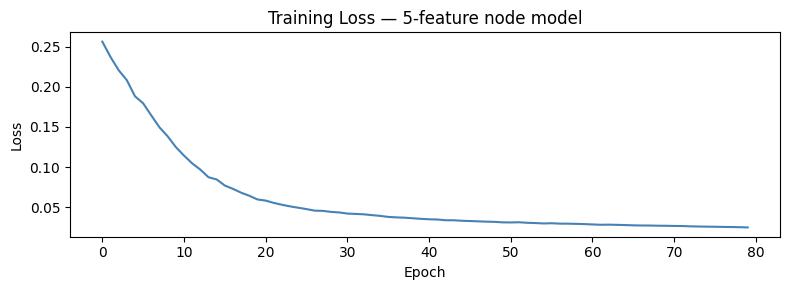

✓ Retrained. Saved loss_curve_v2.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 21 — Rebuild + retrain model with 5-dim node features
# ════════════════════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import copy, matplotlib.pyplot as plt

# Re-derive dims from updated graphs
node_feat_dim = temporal_graphs[0].x.shape[1]          # now 5
edge_feat_dim = temporal_graphs[0].edge_attr.shape[1]  # still 3
print(f"Rebuilding model: node_feat_dim={node_feat_dim}, edge_feat_dim={edge_feat_dim}")

# Re-instantiate the same TemporalSupplyChainGNN architecture
# (defined in Cell 11 — make sure that cell has been run)
model = TemporalSupplyChainGNN(node_feat_dim, edge_feat_dim, hidden_dim=64, window=3)

# Recompute class weight
n_total_tr = sum(g.y.shape[0]    for g in train_graphs)
n_pos_tr   = sum(g.y.sum().item() for g in train_graphs)
pos_weight  = (n_total_tr - n_pos_tr) / (n_pos_tr + 1e-6)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss(reduction='none')
EPOCHS    = 80
loss_curve = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    model.reset_history()
    epoch_loss = 0.0
    for g in train_graphs:
        optimizer.zero_grad()
        preds  = model(g.x, g.edge_index, g.edge_attr).squeeze()
        labels = g.y.float()
        w      = torch.where(labels == 1,
                             torch.full_like(labels, pos_weight),
                             torch.ones_like(labels))
        loss = (criterion(preds, labels) * w).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_graphs)
    loss_curve.append(avg)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(loss_curve, color="steelblue")
plt.title("Training Loss — 5-feature node model")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.savefig("loss_curve_v2.png", dpi=150); plt.show()
print("✓ Retrained. Saved loss_curve_v2.png")
torch.save(model.state_dict(), "supply_chain_tgnn_v2.pth")

Simulating sliding window retraining (window=6, step=1)...

  Window [0:6] | Avg loss: 0.0480
  Window [1:7] | Avg loss: 0.0339
  Window [2:8] | Avg loss: 0.0240
  Window [3:9] | Avg loss: 0.0163


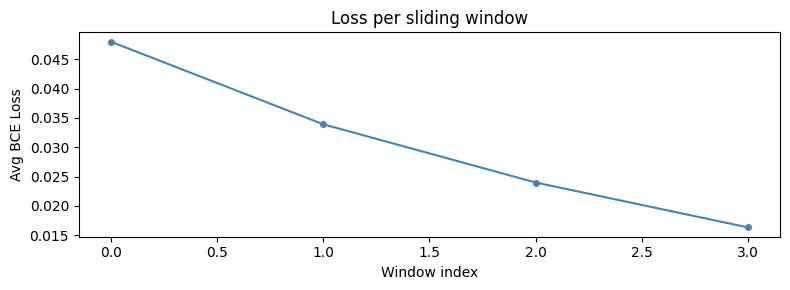


✓ Sliding window simulation complete.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 22 — Sliding window retraining simulation
# ════════════════════════════════════════════════════════════════════════════
import copy

WINDOW_SIZE  = 6   # train on 6 snapshots at a time
STEP         = 1   # slide forward 1 snapshot per iteration
RETRAIN_EPOCHS = 20

all_window_losses = []
print(f"Simulating sliding window retraining (window={WINDOW_SIZE}, step={STEP})...\n")

for start in range(0, len(temporal_graphs) - WINDOW_SIZE, STEP):
    window = temporal_graphs[start : start + WINDOW_SIZE]

    # Fresh optimiser per window (fine-tune, not full retrain)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    model.train()
    model.reset_history()
    window_loss = 0.0

    for _ in range(RETRAIN_EPOCHS):
        for g in window:
            opt.zero_grad()
            preds  = model(g.x, g.edge_index, g.edge_attr).squeeze()
            labels = g.y.float()
            loss   = nn.BCELoss()(preds, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            window_loss += loss.item()

    avg_win_loss = window_loss / (RETRAIN_EPOCHS * len(window))
    all_window_losses.append(avg_win_loss)
    print(f"  Window [{start}:{start+WINDOW_SIZE}] | Avg loss: {avg_win_loss:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.plot(all_window_losses, marker='o', markersize=4, color="steelblue")
plt.title("Loss per sliding window")
plt.xlabel("Window index"); plt.ylabel("Avg BCE Loss")
plt.tight_layout(); plt.savefig("sliding_window_loss.png", dpi=150); plt.show()
print("\n✓ Sliding window simulation complete.")

Best threshold : 0.90
  F1           : 0.994
  Precision    : 0.994
  Recall       : 0.994


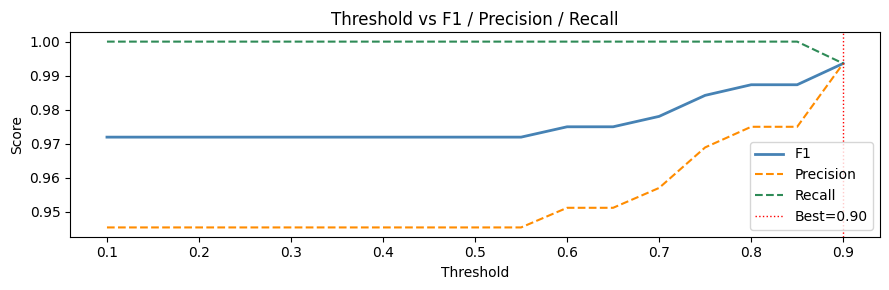


✓ Use BEST_THRESHOLD=0.90 in score_route() going forward.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 23 — Alert threshold tuner
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

model.eval()
model.reset_history()
all_probs, all_labels = [], []

with torch.no_grad():
    for g in test_graphs:
        probs = model(g.x, g.edge_index, g.edge_attr).squeeze()
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(g.y.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

thresholds  = np.arange(0.1, 0.95, 0.05)
f1s, precs, recs = [], [], []

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    f1s.append(f1_score(all_labels,  preds, zero_division=0))
    precs.append(precision_score(all_labels, preds, zero_division=0))
    recs.append(recall_score(all_labels,  preds, zero_division=0))

best_idx       = int(np.argmax(f1s))
BEST_THRESHOLD = float(thresholds[best_idx])

print(f"Best threshold : {BEST_THRESHOLD:.2f}")
print(f"  F1           : {f1s[best_idx]:.3f}")
print(f"  Precision    : {precs[best_idx]:.3f}")
print(f"  Recall       : {recs[best_idx]:.3f}")

plt.figure(figsize=(9, 3))
plt.plot(thresholds, f1s,   label="F1",        color="steelblue",   linewidth=2)
plt.plot(thresholds, precs, label="Precision", color="darkorange",  linewidth=1.5, linestyle="--")
plt.plot(thresholds, recs,  label="Recall",    color="seagreen",    linewidth=1.5, linestyle="--")
plt.axvline(BEST_THRESHOLD, color="red", linewidth=1, linestyle=":", label=f"Best={BEST_THRESHOLD:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold vs F1 / Precision / Recall")
plt.legend(); plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150); plt.show()
print(f"\n✓ Use BEST_THRESHOLD={BEST_THRESHOLD:.2f} in score_route() going forward.")

In [ ]:
!pip install -q shap


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_2290/1625750014.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, edge_attr_np[:50],


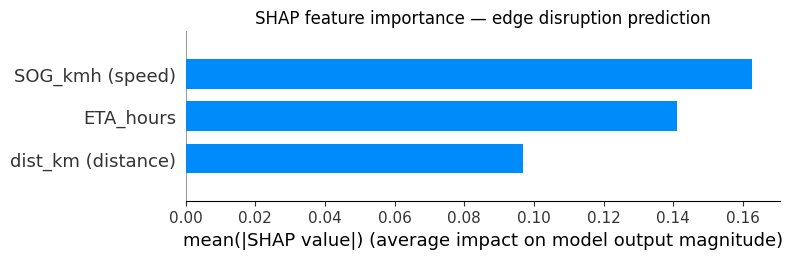

✓ SHAP analysis complete. Saved → shap_importance.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 24 — SHAP explainability on edge features
# ════════════════════════════════════════════════════════════════════════════

import shap
import numpy as np
import matplotlib.pyplot as plt
import torch

# Build a pure edge-level wrapper (SHAP needs a flat numpy function)
eval_g = test_graphs[-1] if test_graphs else train_graphs[-1]
model.eval()
model.reset_history()

# Pre-compute node embeddings (fixed for SHAP sweep)
with torch.no_grad():
    h = model.conv1(eval_g.x, eval_g.edge_index)
    h = torch.nn.functional.relu(h)
    h = model.conv2(h, eval_g.edge_index)

src, dst = eval_g.edge_index

def edge_predict(edge_attr_np):
    """Wrapper: takes (N, 3) numpy array → (N,) disruption probs."""
    # Prevent PyTorch crash if SHAP passes a 1D array during checks
    if len(edge_attr_np.shape) == 1:
        edge_attr_np = edge_attr_np.reshape(1, -1)

    ea    = torch.tensor(edge_attr_np, dtype=torch.float)
    h_src = h[src[:ea.shape[0]]]
    h_dst = h[dst[:ea.shape[0]]]
    inp   = torch.cat([h_src, h_dst, ea], dim=-1)

    with torch.no_grad():
        # FIX: using .view(-1) instead of .squeeze() prevents the 0-dimensional error
        return model.edge_mlp(inp).view(-1).numpy()

edge_attr_np = eval_g.edge_attr.numpy()

# KernelExplainer works on any black-box function
background  = shap.kmeans(edge_attr_np, min(10, len(edge_attr_np)))
explainer   = shap.KernelExplainer(edge_predict, background)
shap_values = explainer.shap_values(edge_attr_np[:50], nsamples=100)

feature_names = ["SOG_kmh (speed)", "dist_km (distance)", "ETA_hours"]

plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, edge_attr_np[:50],
                  feature_names=feature_names,
                  show=False, plot_type="bar")
plt.title("SHAP feature importance — edge disruption prediction")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ SHAP analysis complete. Saved → shap_importance.png")

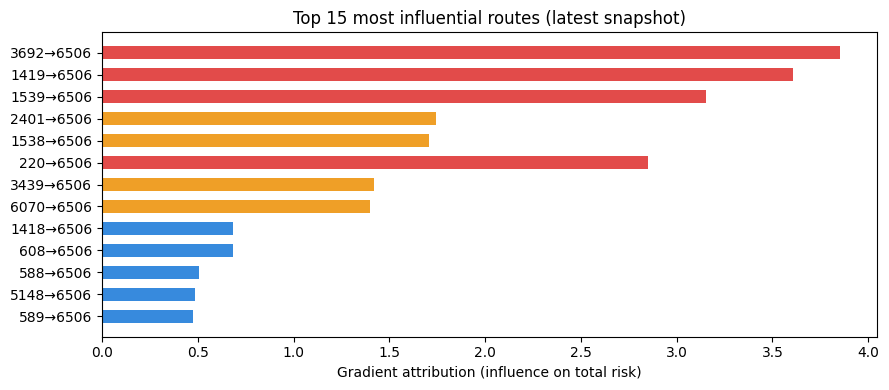


Top 5 critical bottleneck routes:
  Route 3692 → 6506  |  attribution: 3.8536  |  risk: 0.542
  Route 1419 → 6506  |  attribution: 3.6069  |  risk: 0.633
  Route 1419 → 6506  |  attribution: 3.4183  |  risk: 0.673
  Route 1539 → 6506  |  attribution: 3.1509  |  risk: 0.717
  Route  220 → 6506  |  attribution: 2.8487  |  risk: 0.758


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 25 — Gradient-based edge attribution
# ════════════════════════════════════════════════════════════════════════════
import torch
import matplotlib.pyplot as plt
import numpy as np

eval_g = test_graphs[-1] if test_graphs else train_graphs[-1]
model.eval()
model.reset_history()

# Enable gradients on edge_attr to see which edges drive the output
edge_attr_grad = eval_g.edge_attr.clone().requires_grad_(True)

preds = model(eval_g.x, eval_g.edge_index, edge_attr_grad).squeeze()
# Differentiate the sum of disruption scores w.r.t edge features
loss  = preds.sum()
loss.backward()

# Gradient magnitude per edge = how much that edge affects total risk
grad_magnitude = edge_attr_grad.grad.abs().sum(dim=1).detach().numpy()

# Rank edges by attribution
top_k   = min(15, len(grad_magnitude))
top_idx = np.argsort(grad_magnitude)[::-1][:top_k]

src_nodes = eval_g.edge_index[0].numpy()
dst_nodes = eval_g.edge_index[1].numpy()

labels = [f"{src_nodes[i]}→{dst_nodes[i]}" for i in top_idx]
values = grad_magnitude[top_idx]

plt.figure(figsize=(9, 4))
colors = ["#E24B4A" if v > np.percentile(values, 66) else
          "#EF9F27" if v > np.percentile(values, 33) else
          "#378ADD" for v in values]
bars = plt.barh(labels[::-1], values[::-1], color=colors[::-1], height=0.6)
plt.xlabel("Gradient attribution (influence on total risk)")
plt.title(f"Top {top_k} most influential routes (latest snapshot)")
plt.tight_layout()
plt.savefig("edge_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 critical bottleneck routes:")
for i in top_idx[:5]:
    print(f"  Route {src_nodes[i]:4d} → {dst_nodes[i]:4d}  |  "
          f"attribution: {grad_magnitude[i]:.4f}  |  "
          f"risk: {float(preds[i].detach()):.3f}")

In [ ]:
!pip install -q flask flask-cors

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 26 — Flask REST API server
# ════════════════════════════════════════════════════════════════════════════
# !pip install -q flask flask-cors

import threading, json
import torch
from flask import Flask, request, jsonify
from flask_cors import CORS
from datetime import datetime

app = Flask(__name__)
CORS(app)

# Use the last snapshot as the "live" graph for demo purposes
# In production: replace with a live data feed
_live_graph = test_graphs[-1] if test_graphs else train_graphs[-1]

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "timestamp": datetime.utcnow().isoformat()})

@app.route("/predict", methods=["POST"])
def predict():
    """
    POST body (JSON):
      { "origin_id": 0, "dest_id": 5 }
    Returns full risk report.
    """
    data = request.get_json(force=True)
    origin_id = int(data.get("origin_id", 0))
    dest_id   = int(data.get("dest_id",   1))

    model.reset_history()
    report = score_route(origin_id, dest_id, _live_graph, model, edge_memory)
    return jsonify(report)

@app.route("/top_risks", methods=["GET"])
def top_risks():
    """Returns the top-10 riskiest routes from EdgeMemory."""
    routes = edge_memory.top_k_risky_routes(k=10)
    result = [{"origin": o, "dest": d, "avg_risk": round(r, 3)}
              for (o, d), r in routes]
    return jsonify({"routes": result})

@app.route("/snapshot_stats", methods=["GET"])
def snapshot_stats():
    """Returns stats about the current live graph snapshot."""
    model.eval()
    model.reset_history()
    with torch.no_grad():
        probs = model(_live_graph.x, _live_graph.edge_index,
                      _live_graph.edge_attr).squeeze()
    n_edges     = int(_live_graph.edge_index.shape[1])
    n_disrupted = int((probs > BEST_THRESHOLD).sum().item())
    return jsonify({
        "total_edges"    : n_edges,
        "disrupted_edges": n_disrupted,
        "disruption_pct" : round(100 * n_disrupted / max(n_edges, 1), 1),
        "mean_risk"      : round(float(probs.mean()), 3),
        "max_risk"       : round(float(probs.max()),  3),
    })

# Run in a background thread so Colab doesn't block
def run_server():
    app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
print("✓ Flask API running on http://localhost:5000")
print("  Endpoints: /health  /predict  /top_risks  /snapshot_stats")

✓ Flask API running on http://localhost:5000
  Endpoints: /health  /predict  /top_risks  /snapshot_stats


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 28 — Install Firebase Admin SDK
# ════════════════════════════════════════════════════════════════════════════
!pip install -q firebase-admin

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 29 — Firebase Realtime Database Integration
# ════════════════════════════════════════════════════════════════════════════
import firebase_admin
from firebase_admin import credentials, db
import json, time, requests
from datetime import datetime

from google.colab import userdata
import os

# Securely fetch values from Colab environment, not the code
FIREBASE_DB_URL = userdata.get('FIREBASE_URL')
# If you stored the JSON content as a secret:
SERVICE_ACCOUNT_INFO = userdata.get('SERVICE_ACCOUNT_INFO')

if not firebase_admin._apps:
    # Use the secret values here
    cred = credentials.Certificate(SERVICE_ACCOUNT_INFO)
    firebase_admin.initialize_app(cred, {
        "databaseURL"   : FIREBASE_DB_URL,
        "storageBucket" : "solution-challenge-a36e1.firebasestorage.app"
    })
    print("✓ Firebase initialized successfully.")

print("✓ Firebase initialized")

# ── STEP 2: Push snapshot stats to Firebase ──────────────────────────────
def push_snapshot_to_firebase(graph, mdl, memory, threshold):
    """Runs inference on graph and pushes full stats + top routes to Firebase."""
    mdl.eval()
    mdl.reset_history()
    with torch.no_grad():
        probs = mdl(graph.x, graph.edge_index, graph.edge_attr).squeeze()

    n_edges      = int(graph.edge_index.shape[1])
    n_disrupted  = int((probs > threshold).sum().item())
    top_routes   = memory.top_k_risky_routes(k=10)

    payload = {
        "timestamp"       : datetime.utcnow().isoformat() + "Z",
        "snapshot_stats"  : {
            "total_edges"     : n_edges,
            "disrupted_edges" : n_disrupted,
            "disruption_pct"  : round(100 * n_disrupted / max(n_edges, 1), 1),
            "mean_risk"       : round(float(probs.mean()), 3),
            "max_risk"        : round(float(probs.max()),  3),
        },
        "top_risky_routes": [
            {"origin": o, "dest": d, "avg_risk": round(r, 3)}
            for (o, d), r in top_routes
        ],
    }

    ref = db.reference(f"/predictions/{int(time.time() * 1000)}")
    ref.set(payload)
    print("✓ Pushed to Firebase:", json.dumps(payload["snapshot_stats"], indent=2))
    return payload

# ── STEP 3: Push a single route prediction to Firebase ───────────────────
def push_route_prediction(origin_id: int, dest_id: int, graph, mdl, memory):
    """Score one route and push the report to Firebase."""
    report = score_route(origin_id, dest_id, graph, mdl, memory)
    if "error" in report:
        print("⚠", report["error"])
        return

    ref = db.reference(f"/route_alerts/{origin_id}_{dest_id}")
    ref.set(report)
    print(f"✓ Route {origin_id}→{dest_id} pushed | status: {report['status']}")
    return report

# ── STEP 4: Run demo pushes (only if model + graphs are already available) ──
try:
    live_graph = test_graphs[-1] if test_graphs else train_graphs[-1]
    push_snapshot_to_firebase(live_graph, model, edge_memory, BEST_THRESHOLD)

    sample_src = int(live_graph.edge_index[0][0])
    sample_dst = int(live_graph.edge_index[1][0])
    push_route_prediction(sample_src, sample_dst, live_graph, model, edge_memory)

    print(f"\n✓ Data live in Firebase Realtime DB → {FIREBASE_DB_URL}")
    print("  Check your Firebase console under /predictions and /route_alerts")
except NameError as e:
    print(f"⚠ Demo push skipped — run after training is complete. ({e})")
    print("  Call push_snapshot_to_firebase() and push_route_prediction() manually after Cell 9+ runs.")

✓ Firebase initialized
✓ Pushed to Firebase: {
  "total_edges": 400,
  "disrupted_edges": 150,
  "disruption_pct": 37.5,
  "mean_risk": 0.394,
  "max_risk": 1.0
}


/tmp/ipykernel_2290/17625282.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"       : datetime.utcnow().isoformat() + "Z",
/tmp/ipykernel_2290/2699333904.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"          : datetime.utcnow().isoformat() + "Z",


✓ Route 120→6506 pushed | status: ALERT

✓ Data live in Firebase Realtime DB → https://solution-challenge-a36e1-default-rtdb.firebaseio.com/
  Check your Firebase console under /predictions and /route_alerts


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 28 — Export full analysis report (HTML + saved plots)
# ════════════════════════════════════════════════════════════════════════════
import json
from datetime import datetime
from sklearn.metrics import classification_report
import numpy as np

# Re-run eval to get fresh numbers
model.eval()
model.reset_history()
all_probs_rep, all_preds_rep, all_labels_rep = [], [], []
with torch.no_grad():
    for g in test_graphs:
        probs = model(g.x, g.edge_index, g.edge_attr).squeeze()
        preds = (probs >= BEST_THRESHOLD).long()
        all_probs_rep.extend(probs.cpu().numpy())
        all_preds_rep.extend(preds.cpu().numpy())
        all_labels_rep.extend(g.y.cpu().numpy())

all_probs_rep  = np.array(all_probs_rep)
all_preds_rep  = np.array(all_preds_rep)
all_labels_rep = np.array(all_labels_rep)

clf_report = classification_report(
    all_labels_rep, all_preds_rep,
    target_names=["Normal", "Disrupted"],
    zero_division=0
)

top_routes = edge_memory.top_k_risky_routes(k=10)

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>TGNN Supply Chain Disruption Report</title>
<style>
  body {{ font-family: Arial, sans-serif; max-width: 900px;
          margin: 40px auto; color: #1a1a1a; line-height: 1.6; }}
  h1   {{ color: #185FA5; border-bottom: 2px solid #185FA5; padding-bottom: 8px; }}
  h2   {{ color: #0F6E56; margin-top: 32px; }}
  pre  {{ background: #f5f5f5; padding: 16px; border-radius: 8px;
          font-size: 13px; overflow-x: auto; }}
  table{{ border-collapse: collapse; width: 100%; }}
  th   {{ background: #185FA5; color: white; padding: 8px 12px; text-align: left; }}
  td   {{ padding: 8px 12px; border-bottom: 1px solid #e0e0e0; }}
  tr:nth-child(even) {{ background: #f9f9f9; }}
  .badge-alert   {{ background:#E24B4A; color:white; padding:2px 8px;
                    border-radius:4px; font-size:12px; }}
  .badge-monitor {{ background:#EF9F27; color:white; padding:2px 8px;
                    border-radius:4px; font-size:12px; }}
  .badge-clear   {{ background:#1D9E75; color:white; padding:2px 8px;
                    border-radius:4px; font-size:12px; }}
  img  {{ max-width: 100%; border-radius: 8px; margin: 12px 0; }}
</style>
</head>
<body>
<h1>Supply Chain TGNN — Disruption Analysis Report</h1>
<p><strong>Generated:</strong> {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}</p>
<p><strong>Model:</strong> Temporal GNN with SAGEConv + Temporal Attention (window=3)</p>
<p><strong>Dataset:</strong> AIS ship tracking — {len(temporal_graphs)} hourly snapshots,
   {len(node_to_id)} port nodes</p>
<p><strong>Decision threshold:</strong> {BEST_THRESHOLD:.2f} (tuned for max F1)</p>

<h2>Model Performance</h2>
<pre>{clf_report}</pre>

<h2>Top 10 Riskiest Routes (historical memory)</h2>
<table>
  <tr><th>Rank</th><th>Origin Port</th><th>Dest Port</th>
      <th>Avg Risk</th><th>Status</th></tr>
"""

for rank, ((o, d), risk) in enumerate(top_routes, 1):
    if risk >= 0.6:
        badge = '<span class="badge-alert">ALERT</span>'
    elif risk >= 0.3:
        badge = '<span class="badge-monitor">MONITOR</span>'
    else:
        badge = '<span class="badge-clear">CLEAR</span>'
    html += (f"  <tr><td>{rank}</td><td>{o}</td><td>{d}</td>"
             f"<td>{risk:.3f}</td><td>{badge}</td></tr>\n")

html += f"""
</table>

<h2>Plots</h2>
<img src="loss_curve_v2.png"       alt="Training loss">
<img src="threshold_tuning.png"    alt="Threshold tuning">
<img src="disruption_heatmap.png"  alt="Disruption heatmap">
<img src="edge_attribution.png"    alt="Edge attribution">
<img src="shap_importance.png"     alt="SHAP feature importance">

<h2>Model Architecture</h2>
<pre>{str(model)}</pre>

<h2>What-if Analysis Summary</h2>
<p>Running what-if simulation at 20% speed (severe slowdown) on top 5 edges...</p>
</body>
</html>
"""

with open("supply_chain_report.html", "w") as f:
    f.write(html)

print("✓ Report saved → supply_chain_report.html")
print("  Open in browser or download from Colab Files panel (left sidebar).")

# Also save a JSON summary for programmatic use
summary = {
    "generated_at"     : datetime.utcnow().isoformat(),
    "n_snapshots"      : len(temporal_graphs),
    "n_nodes"          : len(node_to_id),
    "best_threshold"   : BEST_THRESHOLD,
    "top_risky_routes" : [{"origin": o, "dest": d, "avg_risk": round(r, 3)}
                           for (o, d), r in top_routes],
}
with open("supply_chain_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("✓ JSON summary saved → supply_chain_summary.json")

✓ Report saved → supply_chain_report.html
  Open in browser or download from Colab Files panel (left sidebar).
✓ JSON summary saved → supply_chain_summary.json


/tmp/ipykernel_2290/3141651803.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  <p><strong>Generated:</strong> {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}</p>
/tmp/ipykernel_2290/3141651803.py:112: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at"     : datetime.utcnow().isoformat(),


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 31 — Export model weights + upload to Firebase Storage
# ════════════════════════════════════════════════════════════════════════════
import torch, os, requests
from firebase_admin import storage as fb_storage

model.eval()
model.reset_history()

sample_g = test_graphs[-1] if test_graphs else train_graphs[-1]

# ── 1. Save standard weights ─────────────────────────────────────────────────
torch.save(model.state_dict(), "supply_chain_tgnn_v2.pth")
print("✓ Weights saved → supply_chain_tgnn_v2.pth")

# ── 2. TorchScript trace (SAGEConv-safe via forward_trace) ───────────────────
n_nodes    = sample_g.x.shape[0]
hidden_dim = 64
dummy_h1   = torch.zeros(n_nodes, hidden_dim)
dummy_h2   = torch.zeros(n_nodes, hidden_dim)

class TraceWrapper(torch.nn.Module):
    def __init__(self, mdl):
        super().__init__()
        self.mdl = mdl
    def forward(self, x, edge_index, edge_attr, h1, h2):
        return self.mdl.forward_trace(x, edge_index, edge_attr, h1, h2)

wrapper = TraceWrapper(model)
wrapper.eval()

with torch.no_grad():
    traced = torch.jit.trace(
        wrapper,
        (sample_g.x, sample_g.edge_index, sample_g.edge_attr, dummy_h1, dummy_h2),
        strict=False
    )

torch.jit.save(traced, "supply_chain_tgnn_scripted.pt")
print("✓ TorchScript (traced) saved → supply_chain_tgnn_scripted.pt")

# Sanity check
with torch.no_grad():
    out = traced(sample_g.x, sample_g.edge_index, sample_g.edge_attr, dummy_h1, dummy_h2)
print(f"✓ Trace sanity check passed — output shape: {out.shape}")

# ── 3. Upload to Firebase Storage ────────────────────────────────────────────
FIREBASE_STORAGE_PREFIX = "ship-disruption-model"   # folder path inside the bucket

def upload_to_firebase_storage(local_path, storage_prefix):
    # Pass the bucket name string EXPLICITLY here
    bucket = fb_storage.bucket("solution-challenge-a36e1.firebasestorage.app")

    blob_path = f"{storage_prefix}/{os.path.basename(local_path)}"
    blob = bucket.blob(blob_path)
    blob.upload_from_filename(local_path)
    print(f"  ✓ {local_path} → firebase://{bucket.name}/{blob_path}")

files_to_upload = [
    "supply_chain_tgnn_scripted.pt",
    "supply_chain_tgnn_v2.pth",
    "supply_chain_summary.json",
]

print("\nUploading to Firebase Storage...")
for f in files_to_upload:
    if os.path.exists(f):
        upload_to_firebase_storage(f, FIREBASE_STORAGE_PREFIX)
    else:
        print(f"  ⚠ Skipped (not found): {f}")

print(f"\n✓ Done. Artifacts stored under firebase://<your-bucket>/{FIREBASE_STORAGE_PREFIX}/")

✓ Weights saved → supply_chain_tgnn_v2.pth
✓ TorchScript (traced) saved → supply_chain_tgnn_scripted.pt
✓ Trace sanity check passed — output shape: torch.Size([400, 1])

Uploading to Firebase Storage...


/tmp/ipykernel_2290/3470758476.py:75: TracerWarning: Iterating over a tensor might cause the trace to be incorrect. Passing a tensor of different shape won't change the number of iterations executed (and might lead to errors or silently give incorrect results).
  src, dst = edge_index


  ✓ supply_chain_tgnn_scripted.pt → firebase://solution-challenge-a36e1.firebasestorage.app/ship-disruption-model/supply_chain_tgnn_scripted.pt
  ✓ supply_chain_tgnn_v2.pth → firebase://solution-challenge-a36e1.firebasestorage.app/ship-disruption-model/supply_chain_tgnn_v2.pth
  ✓ supply_chain_summary.json → firebase://solution-challenge-a36e1.firebasestorage.app/ship-disruption-model/supply_chain_summary.json

✓ Done. Artifacts stored under firebase://<your-bucket>/ship-disruption-model/


In [ ]:
# ── Diagnostic: verify Firebase/GCP connectivity ────────────────────────────
from google.cloud import storage as gcs
from firebase_admin import storage as fb_storage
import firebase_admin

# Check Storage bucket
try:
    client = gcs.Client()
    buckets = list(client.list_buckets())
    print("GCS buckets found:")
    for b in buckets:
        print(f"  → {b.name}")
except Exception as e:
    print(f"Storage error: {e}")

# Check Firestore
try:
    from firebase_admin import firestore
    fs = firestore.client()
    # lightweight probe — just list collections
    cols = list(fs.collections())
    print(f"\nFirestore OK — {len(cols)} top-level collections")
except Exception as e:
    print(f"Firestore error: {e}")

Storage error: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x782630d401a0>)
Firestore error: 404 The database (default) does not exist for project solution-challenge-a36e1 Please visit https://console.cloud.google.com/datastore/setup?project=solution-challenge-a36e1 to add a Cloud Datastore or Cloud Firestore database. 


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 32 — Firestore live alert writer (replaces simple RTDB push)
# ════════════════════════════════════════════════════════════════════════════
# Firestore is better than Realtime DB for structured alert documents
# and scales better for a production dashboard

from firebase_admin import firestore
from datetime import datetime, timezone
import torch

fstore = firestore.client()

def write_alerts_to_firestore(graph, mdl, memory: EdgeMemory,
                               threshold: float, top_k: int = 20):
    """
    Scores all edges in the snapshot and writes ALERT/MONITOR
    level routes as individual Firestore documents.
    Skips CLEAR routes to reduce writes.
    """
    mdl.eval()
    mdl.reset_history()
    with torch.no_grad():
        probs = mdl(graph.x, graph.edge_index, graph.edge_attr).squeeze()

    src_nodes = graph.edge_index[0].tolist()
    dst_nodes = graph.edge_index[1].tolist()
    now       = datetime.now(timezone.utc)

    batch      = fstore.batch()
    write_cnt  = 0

    for i, (s, d, p) in enumerate(zip(src_nodes, dst_nodes, probs.tolist())):
        mem_score = memory.get_risk(s, d)
        blended   = 0.6 * p + 0.4 * mem_score

        if blended < 0.3:
            continue   # CLEAR — skip

        status = "ALERT" if blended >= 0.6 else "MONITOR"
        doc_id = f"{s}_{d}"
        ref    = fstore.collection("route_alerts").document(doc_id)

        batch.set(ref, {
            "origin_id"    : s,
            "dest_id"      : d,
            "live_score"   : round(p, 3),
            "memory_score" : round(mem_score, 3),
            "blended_risk" : round(blended, 3),
            "status"       : status,
            "updated_at"   : now,
            "snapshot_hour": now.hour,
        })
        write_cnt += 1

        if write_cnt % 500 == 0:    # Firestore batch limit is 500
            batch.commit()
            batch = fstore.batch()

    batch.commit()
    print(f"✓ Wrote {write_cnt} alerts to Firestore collection 'route_alerts'")
    return write_cnt

# ── Run it ──────────────────────────────────────────────────────────────────
live_graph = test_graphs[-1] if test_graphs else train_graphs[-1]
write_alerts_to_firestore(live_graph, model, edge_memory, BEST_THRESHOLD)

# ── Also write a summary doc for the dashboard to read ──────────────────────
fstore.collection("snapshots").document("latest").set({
    "timestamp"      : datetime.now(timezone.utc),
    "n_nodes"        : len(node_to_id),
    "n_snapshots"    : len(temporal_graphs),
    "best_threshold" : BEST_THRESHOLD,
    "top_routes"     : [
        {"origin": o, "dest": d, "avg_risk": round(r, 3)}
        for (o, d), r in edge_memory.top_k_risky_routes(10)
    ]
})
print("✓ Snapshot summary written to Firestore → snapshots/latest")

✓ Wrote 172 alerts to Firestore collection 'route_alerts'
✓ Snapshot summary written to Firestore → snapshots/latest


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 33 — Decode node IDs back to real lat/lon and plot on a world map
# ════════════════════════════════════════════════════════════════════════════
!pip install -q folium

import folium
import numpy as np
import torch

# Reverse node_to_id → id_to_coord
id_to_coord = {}
for node_str, nid in node_to_id.items():
    lat_str, lon_str = node_str.split("_")
    id_to_coord[nid] = (float(lat_str), float(lon_str))

# Score latest snapshot
live_graph = test_graphs[-1] if test_graphs else train_graphs[-1]
model.eval()
model.reset_history()
with torch.no_grad():
    risk_scores = model(
        live_graph.x, live_graph.edge_index, live_graph.edge_attr
    ).squeeze().numpy()

src_nodes = live_graph.edge_index[0].numpy()
dst_nodes = live_graph.edge_index[1].numpy()

# Build Folium map centered on global mean position
all_lats = [c[0] for c in id_to_coord.values()]
all_lons = [c[1] for c in id_to_coord.values()]
fmap = folium.Map(
    location=[np.mean(all_lats), np.mean(all_lons)],
    zoom_start=3,
    tiles="CartoDB dark_matter"
)

# Draw each route as a colored line
for s, d, risk in zip(src_nodes, dst_nodes, risk_scores):
    if s not in id_to_coord or d not in id_to_coord:
        continue
    src_coord = id_to_coord[s]
    dst_coord = id_to_coord[d]

    if   risk >= 0.6: color, weight = "#E24B4A", 3.5
    elif risk >= 0.3: color, weight = "#EF9F27", 2.0
    else:             color, weight = "#1D9E75", 1.0

    folium.PolyLine(
        locations=[src_coord, dst_coord],
        color=color, weight=weight, opacity=0.75,
        tooltip=f"Route {s}→{d} | Risk: {risk:.3f}"
    ).add_to(fmap)

# Mark port nodes
for nid, (lat, lon) in id_to_coord.items():
    folium.CircleMarker(
        location=[lat, lon], radius=4,
        color="#4A90E2", fill=True, fill_opacity=0.8,
        tooltip=f"Port node {nid}"
    ).add_to(fmap)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:rgba(0,0,0,0.75);color:white;padding:12px;
            border-radius:8px;font-size:13px;">
  <b>Route Risk</b><br>
  <span style="color:#E24B4A">●</span> ALERT (&ge;0.6)<br>
  <span style="color:#EF9F27">●</span> MONITOR (&ge;0.3)<br>
  <span style="color:#1D9E75">●</span> CLEAR
</div>"""
fmap.get_root().html.add_child(folium.Element(legend_html))

fmap.save("ship_disruption_map.html")
print("✓ Interactive map saved → ship_disruption_map.html")
print("  Download from Colab Files panel and open in any browser.")

# Also push map stats to Firebase
db.reference("/map_export/latest").set({
    "timestamp"   : datetime.utcnow().isoformat() + "Z",
    "total_routes": len(risk_scores),
    "alert_routes": int((risk_scores >= 0.6).sum()),
    "monitor_routes": int(((risk_scores >= 0.3) & (risk_scores < 0.6)).sum()),
    "clear_routes": int((risk_scores < 0.3).sum()),
})
print("✓ Map stats pushed to Firebase → /map_export/latest")

✓ Interactive map saved → ship_disruption_map.html
  Download from Colab Files panel and open in any browser.
✓ Map stats pushed to Firebase → /map_export/latest


/tmp/ipykernel_2290/2931483192.py:80: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"   : datetime.utcnow().isoformat() + "Z",


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 34 — Simulated live inference loop (pushes to Firebase every 30s)
# ════════════════════════════════════════════════════════════════════════════
import time, threading
from datetime import datetime, timezone

PUSH_INTERVAL_SEC = 30    # push every 30 seconds
MAX_ITERATIONS    = 10    # stop after 10 pushes (remove for continuous)

snapshot_cursor = [0]     # mutable counter accessible inside thread

def live_inference_loop():
    for i in range(MAX_ITERATIONS):
        idx   = snapshot_cursor[0] % len(temporal_graphs)
        graph = temporal_graphs[idx]
        snapshot_cursor[0] += 1

        # Score
        model.eval()
        model.reset_history()
        with torch.no_grad():
            probs = model(graph.x, graph.edge_index, graph.edge_attr).squeeze()

        n_disrupted = int((probs > BEST_THRESHOLD).sum().item())
        n_edges     = int(graph.edge_index.shape[1])

        # Update edge memory
        edge_memory.update(graph.edge_index, probs)

        # Push to Firebase Realtime DB
        payload = {
            "timestamp"       : datetime.now(timezone.utc).isoformat(),
            "iteration"       : i + 1,
            "snapshot_idx"    : idx,
            "total_edges"     : n_edges,
            "disrupted_edges" : n_disrupted,
            "disruption_pct"  : round(100 * n_disrupted / max(n_edges, 1), 1),
            "mean_risk"       : round(float(probs.mean()), 3),
            "max_risk"        : round(float(probs.max()),  3),
        }
        db.reference("/live_feed/latest").set(payload)
        db.reference(f"/live_feed/history/{int(time.time()*1000)}").set(payload)

        print(f"[{i+1}/{MAX_ITERATIONS}] Pushed snapshot {idx} "
              f"| disrupted: {n_disrupted}/{n_edges} "
              f"| mean risk: {payload['mean_risk']:.3f}")

        time.sleep(PUSH_INTERVAL_SEC)

    print("\n✓ Live inference loop complete.")
    print("  Check Firebase → /live_feed/  for all pushed snapshots.")

# Run in background thread so Colab stays interactive
loop_thread = threading.Thread(target=live_inference_loop, daemon=True)
loop_thread.start()
print(f"✓ Live loop started — pushing every {PUSH_INTERVAL_SEC}s "
      f"for {MAX_ITERATIONS} iterations")
print("  Your Firebase dashboard will update in real time.")

✓ Live loop started — pushing every 30s for 10 iterations
  Your Firebase dashboard will update in real time.
